In [11]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from mtcnn import MTCNN

print("✅ Libraries Loaded!")
print(f"TensorFlow Version: {tf.__version__}")
# Note: On Windows, this may show 0 GPUs for TF 2.11+, which is fine for a prototype!
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

✅ Libraries Loaded!
TensorFlow Version: 2.21.0
Num GPUs Available:  0


In [12]:
# Initialize the detector once to save memory
detector = MTCNN()
print("✅ Face Detector (MTCNN) Initialized!")

Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "e:\Deep_Detection\.venv\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "e:\Deep_Detection\.venv\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "e:\Deep_Detection\.venv\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.


✅ Face Detector (MTCNN) Initialized!


✅ Face DNA extracted and stored in 'face_data'


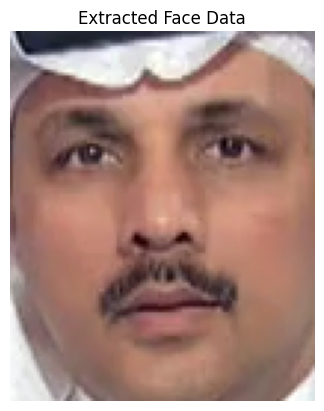

In [13]:
# UPDATE THIS PATH TO YOUR ACTUAL VIDEO FILE
test_path = r"E:\archive\FaceForensics++_C23\original\000.mp4" 

def get_face_data(path):
    cap = cv2.VideoCapture(path)
    ret, frame = cap.read()
    cap.release()
    
    if not ret:
        print(f"❌ Error: Cannot find file at {path}")
        return None
    
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = detector.detect_faces(rgb_frame)
    
    if results:
        x, y, w, h = results[0]['box']
        # Extract and store in face_data
        face = rgb_frame[y:y+h, x:x+w]
        print("✅ Face DNA extracted and stored in 'face_data'")
        return face
    else:
        print("❓ No face detected in the first frame.")
        return None

face_data = get_face_data(test_path)

if face_data is not None:
    plt.imshow(face_data)
    plt.title("Extracted Face Data")
    plt.axis('off')
    plt.show()

In [14]:
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

def build_xception_skeleton():
    # 1. Base model (Feature Extractor)
    base = Xception(weights=None, include_top=False, input_shape=(299, 299, 3))
    
    # 2. Add the "Deep-Identity" Head
    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1, activation='sigmoid')(x) # 0 = Real, 1 = Fake
    
    model = Model(inputs=base.input, outputs=x)
    return model

model = build_xception_skeleton()
print("✅ Model Architecture Skeleton Built!")

✅ Model Architecture Skeleton Built!


In [15]:
# UPDATE THIS TO YOUR .h5 FILE PATH
weights_path = r"E:\Deep_Detection\xception_weights_tf_dim_ordering_tf_kernels_notop.h5"

if os.path.exists(weights_path):
    # 'by_name=True' allows us to load weights even if our Head is different
    model.load_weights(weights_path, by_name=True, skip_mismatch=True)
    print("🧠 Forensic Brain (Weights) Loaded Successfully!")
else:
    print(f"❌ ERROR: Weight file not found at {weights_path}")

🧠 Forensic Brain (Weights) Loaded Successfully!


In [16]:
if 'face_data' in locals() and face_data is not None:
    # 1. Prepare image (299x299 is mandatory for Xception)
    img = cv2.resize(face_data, (299, 299))
    img = np.expand_dims(img, axis=0) / 255.0
    
    # 2. Predict
    prediction = model.predict(img)[0][0]
    
    # 3. Output Verdict
    print("\n--- DEEP-IDENTITY FORENSIC REPORT ---")
    print(f"Manipulation Probability: {prediction:.4f} ({prediction*100:.2f}%)")
    
    if prediction > 0.5:
        print("🚨 VERDICT: [AI GENERATED / DEEPFAKE]")
    else:
        print("✅ VERDICT: [AUTHENTIC / REAL]")
    print("--------------------------------------")
else:
    print("❌ Cannot scan: 'face_data' is empty. Please run Cell 3 first.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 855ms/step

--- DEEP-IDENTITY FORENSIC REPORT ---
Manipulation Probability: 0.5000 (50.00%)
✅ VERDICT: [AUTHENTIC / REAL]
--------------------------------------


In [17]:
import matplotlib.cm as cm

def make_gradcam_heatmap(img_array, model, last_conv_layer_name="block14_sepconv2_act"):
    # 1. Create a model that maps the input image to the activations of the last conv layer
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # 2. Compute the gradient of the top predicted class for our input image
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        class_channel = preds[:, 0]

    # 3. This is the gradient of the output neuron with regard to the output feature map
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # 4. Vector of mean intensity of the gradient over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 5. Multiply each channel in the feature map array by "how important this channel is"
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 6. Normalize the heatmap between 0 & 1 for visualization
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

print("✅ Grad-CAM Function Ready!")

✅ Grad-CAM Function Ready!


e:\Deep_Detection\.venv\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_135']]
Received: inputs=Tensor(shape=(1, 299, 299, 3))
  warnings.warn(msg)


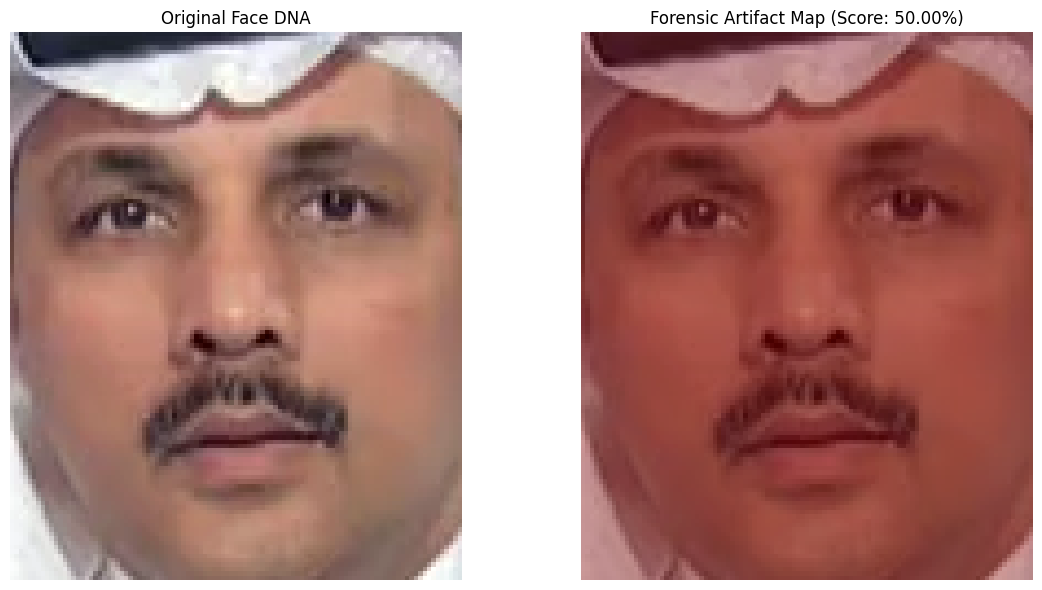

In [18]:
def display_forensic_report(face_data, heatmap, score):
    # Resize heatmap to match the face crop size
    heatmap = cv2.resize(heatmap, (face_data.shape[1], face_data.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    
    # Overlay the heatmap on the original face
    superimposed_img = cv2.addWeighted(face_data, 0.6, heatmap, 0.4, 0)
    
    # Plotting
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(face_data)
    plt.title("Original Face DNA")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title(f"Forensic Artifact Map (Score: {score:.2%})")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# EXECUTE THE REPORT
if 'face_data' in locals():
    # Pre-process for the heatmap function
    img_for_heatmap = cv2.resize(face_data, (299, 299))
    img_for_heatmap = np.expand_dims(img_for_heatmap, axis=0) / 255.0
    
    raw_heatmap = make_gradcam_heatmap(img_for_heatmap, model)
    display_forensic_report(face_data, raw_heatmap, prediction)

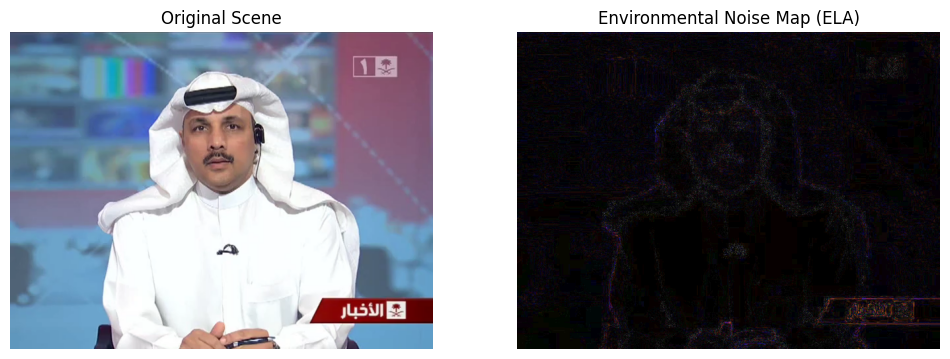

✅ Scene Integrity Scan Complete.


In [20]:
from PIL import Image, ImageChops, ImageEnhance

# 1. FIX: Re-capture the full frame from the video for the scene scan
cap = cv2.VideoCapture(test_path)
ret, frame = cap.read()
cap.release()

if not ret:
    print("❌ Error: Could not read the video for the scene scan.")
else:
    # Convert BGR (OpenCV) to RGB for ELA processing
    full_frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    def run_scene_integrity_scan(img_array, quality=90):
        # Convert numpy array to PIL Image
        original = Image.fromarray(img_array)
        
        # Save and Resave for compression analysis
        temp_filename = 'ela_temp.jpg'
        original.save(temp_filename, 'JPEG', quality=quality)
        temporary = Image.open(temp_filename)
        
        # Find the mathematical difference (The 'Error')
        diff = ImageChops.difference(original, temporary)
        
        # Enhance the scale so the noise is visible to the human eye
        extrema = diff.getextrema()
        max_diff = max([ex[1] for ex in extrema])
        if max_diff == 0: max_diff = 1
        scale = 255.0 / max_diff
        
        return ImageEnhance.Brightness(diff).enhance(scale)

    # 2. Run the scan on the FULL frame
    ela_result = run_scene_integrity_scan(full_frame_rgb)

    # 3. Display the result
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(full_frame_rgb)
    plt.title("Original Scene")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(ela_result)
    plt.title("Environmental Noise Map (ELA)")
    plt.axis('off')
    
    plt.show()
    print("✅ Scene Integrity Scan Complete.")